# 1. Features Exploration
Explore numerical features of Adult Income dataset, namely `fnlwgt`, `capital-gain`, `capital-loss`, `hours-per-week`.

## Import Required Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import neighbors

## Read dataset from file

In [2]:
columns = ["age", "work-class", "fnlwgt", "education", "education-num", "marital-status",
           "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
           "hours-per-week", "native-country", "income"]
adult_data = pd.read_csv('adult.data', names=columns, sep=',', na_values='?', skipinitialspace=True)

## Use k-NN to gather accuracy statistics

In [ ]:
accuracies = {}

for feature in ['fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']:
    data = adult_data[['age', 'education-num', feature, 'income']]
    data = data.drop_duplicates(subset=['age', 'education-num', feature])
    
    X = data[['age', 'education-num', feature]]
    X = StandardScaler().fit_transform(X)
    y = data['income'].to_numpy()

    accuracies[feature] = []
    for i in range(100):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

        test_accuracies = []
        for n_neighbors in range(1, 100):
            clf = neighbors.KNeighborsClassifier(n_neighbors)
            clf.fit(X_train, y_train)
            
            y_pred = clf.predict(X_test)
            accuracy = (y_pred == y_test).mean()
            test_accuracies.append(accuracy)

        accuracies[feature].append(test_accuracies)
        print(feature, i, sum(test_accuracies) / len(test_accuracies))

## Plot the Results

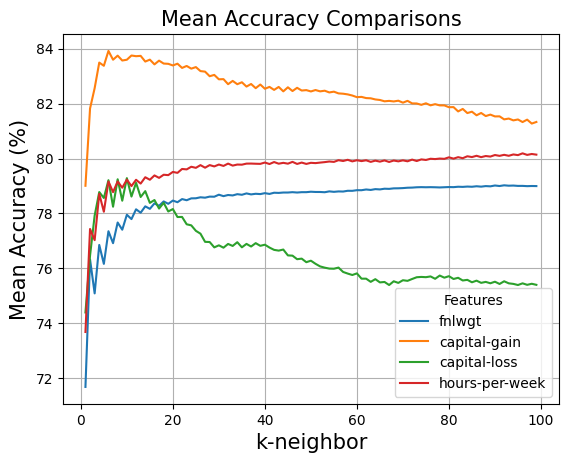

In [16]:
fig, ax = plt.subplots()
for feature in accuracies.keys():
    mean_accuracies = np.array(accuracies[feature]).mean(axis=0)
    ax.plot(range(1, 100), mean_accuracies*100, label=feature)

ax.grid()
ax.set_xlabel('k-neighbor', fontsize=15)
ax.set_ylabel('Mean Accuracy (%)', fontsize=15)
ax.set_title('Mean Accuracy Comparisons', fontsize=15)
plt.legend(title='Features')

# plt.savefig('Features Exploration - Mean Accuracy Comparisons.png', transparent=True, bbox_inches='tight')
plt.show()